# Tutorial: Training a MoGP model

This notebook provides a guide on how to load/normalize data, train a MoGP, and interact with the model. 

In [2]:
%matplotlib inline

import numpy as np
import joblib
import matplotlib
import matplotlib.pyplot as plt

import mogp

## Load data
MoGP priors are scaled to assume that Y has been z-score normalized, and that X values are provided in years. The priors for the model have been tuned for the ALSFRS-R use case. See below section on "Adjusting Gaussian process priors to non-ALS use cases" if your project is in a different setting.

**X** (np.ndarray): explanatory variable (time since symptom onset, in years)  

**Y** (np.ndarray): responses (clinical scores)  

**Matrix size for X and Y:** N x T (N - # patients, T - # time points)   
If participants have varying number of clinical visits, set # time points to max number of visits, and pad end of arrays with fewer visits with NaN values

**Onset Anchor:** If desired, add onset anchor (artificial datapoint at date of symptom). 
If chose to not add onset anchor, set MoGP onset_anchor flag=False when training MoGP

In [6]:
X, Y = mogp.utils.generate_toy_data(seed=0)

#print(X, Y)
print(X, Y)
print(type(X))


# Add onset anchor to matrix
num_pat = X.shape[0]
onset_anchor = 48 # normal onset anchor for ALSFRS-R scores
X = np.hstack((np.zeros((num_pat,1)), X))
Y = np.hstack((onset_anchor * np.ones((num_pat,1)), Y))
print(X, Y)

[[3.85969396 3.88681318 4.25906729 5.03480663]
 [3.02321812 3.11935176 4.55666938 6.25323371]
 [2.74574648 3.74937495 5.56290276 6.74927305]
 [0.5901488  0.70119217 4.01950747 6.4866168 ]
 [0.23950694 5.46928158 5.84507693 6.10308382]
 [4.38443809 5.34158753 5.39747569 5.93585503]
 [3.35482328 3.43005986 4.91976306 5.83400675]
 [3.79366684 4.24398582 4.56554497 5.32270107]
 [3.0563694  4.368451   4.70530185 4.85290649]
 [4.83628717 4.85080199 5.0454609  5.83124424]
 [0.27465387 1.14257291 1.36739267 2.12313047]
 [0.47388626 0.71010943 2.03362347 2.04484982]
 [1.01474222 1.15476124 1.37194439 1.75357063]
 [0.39592995 0.5677976  0.70574259 2.96628413]
 [0.80883422 0.83454565 1.45230124 1.99401414]
 [0.53046305 0.63891351 0.71998138 2.6596854 ]
 [0.47869498 0.86667121 1.53802817 3.3018736 ]
 [0.47478379 1.92773969 3.36798514 3.90819191]
 [0.25283239 2.45889753 2.98312796 3.90936824]
 [0.5630381  0.56876659 1.20294715 1.25494677]
 [3.85969396 3.88681318 4.25906729 5.03480663]
 [3.02321812 

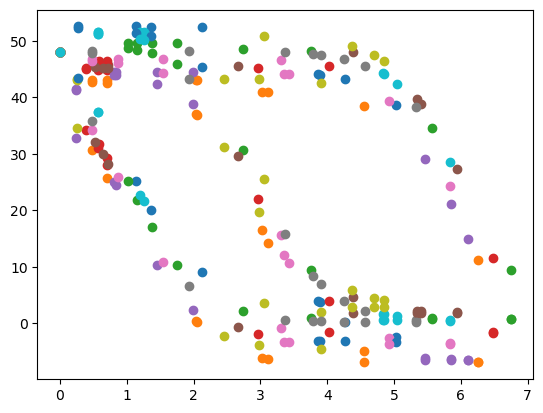

In [4]:
# Visualize Toy Data
for i in range(num_pat):
    _ = plt.plot(X[i], Y[i], 'o')

## Train MoGP model
MoGP model requires X, Y, and alpha as parameters

**alpha** (float): Dirichlet Process scaling parameter; can influence the degree of cluster discretization and therefore the number of identified clusters.  
To estimate alpha, we use ``` alpha = number_init_clusters / np.log10(number_patients) ```, where `number_init_clusters` is a rough guess at number of clusters that may be present in data. The actual number of clusters will be optimized through model training. 

In [5]:
# Provide output directory for model
save_dir = './test'

In [6]:
# Train model
mix = mogp.MoGP_constrained(X=X, Y=Y, alpha=1., num_iter=10, savepath=save_dir, rand_seed=0, normalize=True)
mix.sample()


03:43:26 - MOGP: INFO - Cluster Initialization: [ 6 30 12  6  6]
03:43:26 - MOGP: INFO - Saved Model: C:\Users\21801992t\OneDrive - Université de Tours\Teams\Suivi Guillaume\Workspace\knime-workspace\Python\MoGP\test\MoGP_constrained_iterinit.pkl
03:43:31 - MOGP: INFO - Iter 1: [40  6 14]
03:43:35 - MOGP: INFO - Iter 2: [33  4 23]
03:43:37 - MOGP: INFO - Iter 3: [22 16 22]
03:43:38 - MOGP: INFO - Iter 4: [24 17 19]
03:43:40 - MOGP: INFO - Iter 5: [19 20 21]
03:43:41 - MOGP: INFO - Iter 6: [20 19 21]
03:43:42 - MOGP: INFO - Iter 7: [21 19 20]
03:43:43 - MOGP: INFO - Iter 8: [20 19 21]
03:43:44 - MOGP: INFO - Iter 9: [21 19 20]
03:43:44 - MOGP: INFO - Saved Model: C:\Users\21801992t\OneDrive - Université de Tours\Teams\Suivi Guillaume\Workspace\knime-workspace\Python\MoGP\test\MoGP_constrained.pkl


# Interact with model

MoGP consists of two modules: allocmodel and obsmodel. Relevant fields for each listed below.

**allocmodel** stores properties of the Dirichlet process (DP) clustering model (ex: cluster ids, number of participants in each cluster).   
- alpha (float): DP concentration prior
- Nk (np.array): List of the number of clusters in each cluster component in DP model.
- N (int): Total number of patients in model training data

**obsmodel** stores properties of each cluster's specific Gaussian process regression models. obsmodel is a dictionary of all cluster components, indexed by cluster id (Ex: to access the GP model of a specific cluster, use ```obsmodel[cluster_id].model```)
- model (GPy model object): obsmodel is built off of [GPy](https://sheffieldml.github.io/GPy/) and GPy functions can be used on the model object of a specific cluster
- ll (float): GP regression model log likelihood


### Get number of clusters and their IDs

In [7]:
# Only get cluster IDs if the cluster has at least 1 participant included; disregard all cluster components that have no participants
active_cluster_ids = np.where(mix.allocmodel.Nk>0)[0]
print('Model has {} clusters'.format(len(active_cluster_ids)))
print('Active Cluster IDs: {}'.format(active_cluster_ids))

Model has 3 clusters
Active Cluster IDs: [1 2 3]


### Get cluster assignments for each patient

The z field of the mogp object contains an array of cluster assignments. These are ordered in the same order as the X and Y vectors passed in to the model.

In [8]:
mix.z
print(len(mix.z))

60


### Visualize clusters in MoGP

AttributeError: 'GPRegression' object has no attribute 'plot_mean'

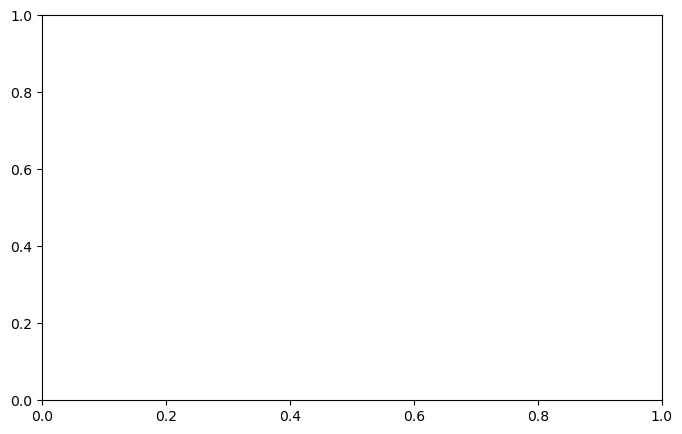

In [13]:
# Legend indicates number of participants in each cluster
fig, ax = plt.subplots(figsize=(8,5))
ax = mogp.utils.plot_mogp(ax=ax, model=mix)

### Use GPy methods to interact with model
obsmodel is a dictionary of GPy models; accessing the model field of a obsmodel cluster allows you to use all of [GPy's](https://sheffieldml.github.io/GPy/) functions

In [16]:
# Get the learned Gaussian Process parameters for one of the cluster, using its active cluster ID
cur_clust = active_cluster_ids[0]
mix.obsmodel[cur_clust].model

GP_regression.,value,constraints,priors
neg_linmap.A,[0.28341388],+ve,"Ga(2.2, 3.3)"
rbf.variance,1.0,+ve fixed,
rbf.lengthscale,1.577059753894989,+ve,"Ga(1.8, 0.44)"
Gaussian_noise.variance,0.013348237935366793,+ve,"Ga(9, 12)"


NameError: name 'cur_clust' is not defined

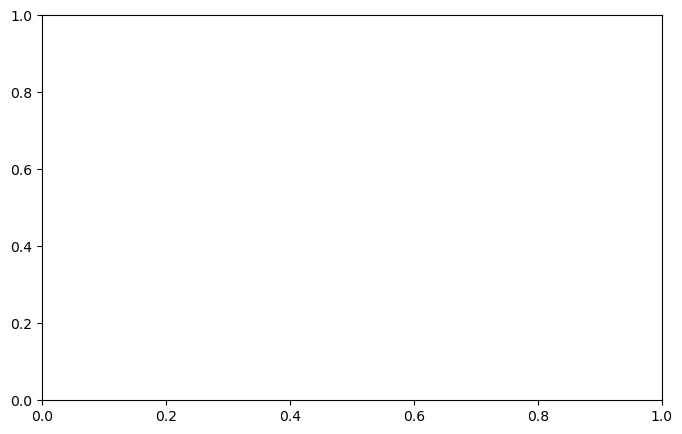

In [14]:
# Plot mean function of this cluster
fig, ax = plt.subplots(figsize=(8,5))
_ = mix.obsmodel[cur_clust].model.plot_mean(ax=ax)
_ = mix.obsmodel[cur_clust].model.plot_confidence(ax=ax)

# Getting the best model and scaling number of iterations

MoGP can be time consuming to run, so our model periodically outputs model files to your saved directory. For final results, we recommend running the model for 100 iterations. After our 'burn-in' period of 25 iterations, the model will start saving a MAP (maximum a posteriori probability) model, which indicates that model had the best log likelihood of all previously generated models. 

The logger for the model will indicate when a new MAP model has been saved:  
Example: `04:26:59 - MOGP: INFO - At iteration 28, Previous Best 77.70252573010355, Current Best 77.70252782040932`

For your final results, you will want to use this MAP model. It is indicated by the `_MAP.pkl` suffix.  
Example below: To get the MAP file, load the `MoGP_constrained_MAP.pkl` object. And then interact with model as shown above.

In [15]:
mix = mogp.MoGP_constrained(X=X, Y=Y, alpha=1., num_iter=30, savepath=save_dir, rand_seed=0, normalize=True)
mix.sample()

06:56:45 - MOGP: INFO - Cluster Initialization: [ 6 30 12  6  6]
06:56:45 - MOGP: INFO - Saved Model: C:\Users\21801992t\OneDrive - Université de Tours\Teams\Suivi Guillaume\Workspace\knime-workspace\Python\MoGP\test\MoGP_constrained_iterinit.pkl
06:56:55 - MOGP: INFO - Iter 1: [40  6 14]
06:57:01 - MOGP: INFO - Iter 2: [33  4 23]
06:57:05 - MOGP: INFO - Iter 3: [22 16 22]
06:57:08 - MOGP: INFO - Iter 4: [24 17 19]
06:57:11 - MOGP: INFO - Iter 5: [19 20 21]
06:57:14 - MOGP: INFO - Iter 6: [20 19 21]
06:57:16 - MOGP: INFO - Iter 7: [21 19 20]
06:57:19 - MOGP: INFO - Iter 8: [20 19 21]
06:57:21 - MOGP: INFO - Iter 9: [21 19 20]
06:57:23 - MOGP: INFO - Iter 10: [20 19 21]
06:57:26 - MOGP: INFO - Iter 11: [20 19 21]
06:57:29 - MOGP: INFO - Iter 12: [21 18 21]
06:57:31 - MOGP: INFO - Iter 13: [20 19 21]
06:57:33 - MOGP: INFO - Iter 14: [20 19 21]
06:57:35 - MOGP: INFO - Iter 15: [20 19 21]
06:57:37 - MOGP: INFO - Iter 16: [19 20 21]
06:57:39 - MOGP: INFO - Iter 17: [20 19 21]
06:57:42 - MOG

In [ ]:
# your model is now loaded in the map_model object below. Instead of the mix object you generated previously, use this.
map_model = joblib.load('test/MoGP_constrained.pkl')

In [ ]:
fig, ax = plt.subplots(figsize=(8,5))
ax = mogp.utils.plot_mogp(ax=ax, model=map_model)

# Adjusting Gaussian process priors to non-ALS use cases

Gaussian processes have priors that define the user's expectation of what properties they want their function to have. 

Gaussian processes take the form:  

$$ f(x) \varpropto  GP(m(x), k(x, x')) $$

where $m(x)$ describes the model’s mean function and $k(x,x’)$ describes the model’s covariance function. 

To specify the covariance function, the Gaussian processes in this implementation of MoGP uses the SE kernel, with the form: 

$$ k(x, x') = \sigma^2exp\dfrac{-(x-x')^2}{2l^2} $$

where $\sigma^2$ is the signal variance and $l$ is the length-scale. The signal variance ($\sigma^2$) determines the average distance of the function from the mean. The length-scale $l$ specifies the smoothness of the function, with increasing length-scales resulting in smoother functions. 

Our model has been tuned for a ALSFRS-R used case, in which we expect smooth functions over a maximum duration of 8 year timescales (the point at which ALSFRS-R data becomes sparse). For the length-scale, a gamma prior with a mean of 4 and variance of 9 was used. The length-scale prior mean value of 4 is approximately half of the maximum trajectory duration included in our model, selected to encourage roughly one mean function crossing in the max duration of 8 years.

These GP priors are learned in the training proces. However, if you use drastically different x-scales (for example, weeks instead of years), you'll notice that the properties of your learned model can vary, especially if your data is noisy.

**If you are applying the model to alternate datasets, you may want to play around with priors to fit your use-case. You can do this in two ways:**

1) Adjust the scale of your x-data  
To get smoother functions, you can experiment with converting your data to longer timescales (ex: converting weeks to years). To get functions with more perturbations, you can do the inverse.

2) Modify the priors directly in the obsmodel.py file:  
You can change line 28: `C.lengthscale.set_prior(GPy.priors.Gamma.from_EV(4., 9.), warning=False)` with varying mean and variances for the GP prior.

Decreasing the mean value of this prior will cause more wiggly functions. Increasing the mean will result in smoother functions.

# Adjust monotonicity biases

The model is biased towards monotonically declining functions. To turn off the monotonicity biases (comprised of the mean function and the threshold function), set the params: **mean_func=False, threshold=None**. These are detailed in our [supplemental methods](https://static-content.springer.com/esm/art%3A10.1038%2Fs43588-022-00299-w/MediaObjects/43588_2022_299_MOESM1_ESM.pdf) (pg 15), under 'monotonic inductive bias'.

Example:   
`mix = mogp.MoGP_constrained(X=X, Y=Y, alpha=1., num_iter=10, savepath=save_dir, rand_seed=0, normalize=True, mean_func=False, threshold=None)`

If you want monotonically increasing functions, the easiest way to do this is to invert your Y-scale and then train the model.